In [14]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import f1_score
from pathlib import Path
import os
import numpy as np
import random


from src.utils import load_env, set_seed, load_json, save_to_json, get_logger, set_seed
from src.experiment_config import ExperimentConfig
from src.data_loading import DatasetLoader
from experiments.cluster_lr import load_filtered_raw_data
from analysis.utils import set_matplot_style, blue_hex, teal_hex, orange_hex, red_hex

set_matplot_style()
env_vars = load_env()
logger = get_logger("cluster_lr_eval")
set_seed(env_vars["RANDOM_SEED"])

In [15]:
LR_RESULTS_DIR = f"/Users/alexleto/projects/metaphor-detector/results/cluster_lr"
K_THRESH = 1000 # inclusive, for final plot
PLOT_PATH = f"{env_vars["RESULTS_DIR"]}/workshop_plots/lr_results"
os.makedirs(PLOT_PATH, exist_ok=True)
set_seed(42)

In [16]:
# set up config and data loader
concept_config = ExperimentConfig(
    dataset="tweets_immigration",
    labeled_only=True,
    task_type="evaluate_results",
    task_name="cluster_lr_results",
    logger=logger,
    env_vars=env_vars
)
data_loader = DatasetLoader(concept_config)
tweets_labeled_res_path = f"{LR_RESULTS_DIR}/{concept_config.dataset_out_name}/LABEL"

In [17]:
def get_random_baseline(data_filtered, label):
    # check that label in data columns
    if label not in data_filtered.columns:
        print(f"User specified label {label} not in data. Try: {data_filtered.columns}")
        raise ValueError

    print(f"Loaded {len(data_filtered)} doc entries")
    y_true = data_filtered[label].tolist()

    random_ops = list(set(y_true))

    import random
    random.seed(42)
    random_preds = [random.choice(random_ops) for _ in y_true]

    random_macro_f1 = f1_score(y_true, random_preds, average='macro')
    return random_macro_f1

In [18]:
def collect_results(path):
    res = {}
    for file_path in Path(path).iterdir():
        if file_path.is_file() and ".csv" in str(file_path):
            filename = str(file_path).split("/")[-1]

            k = int(filename.split("_")[-1].replace(".csv", ""))
            setting = filename.split("_")[0]
            setting = "t25" if setting == "t25" else "all"

            if k not in res:
                res[k] = {}
            res[k][setting] = pd.read_csv(file_path).set_index("Unnamed: 0")
    return res

In [19]:
concept_res_path = tweets_labeled_res_path.replace("LABEL", "concept")
concept_met_clust_path = f"{concept_res_path}/kmeans/mets_only_qwen_expl/"
concept_met_clust_res = collect_results(concept_met_clust_path)

In [20]:
concept_sc_met_clust_path = f"{concept_res_path}/pckmeans/mets_only_qwen_expl/"
concept_sc_met_clust_res = collect_results(concept_sc_met_clust_path)

In [21]:
concept_met_or_clust_path = f"{concept_res_path}/kmeans/mets_only_qwen_expl_old_results/"
concept_met_or_clust_res = collect_results(concept_met_or_clust_path)

In [22]:
# get random baseline - load results, predict over them
raw_data_dict = load_filtered_raw_data(concept_config.dataset, concept_config.labeled_only, ["concept"], True, logger, data_loader)
df = pd.DataFrame.from_dict(raw_data_dict, orient='index')
random_macro_f1 = get_random_baseline(df, "concept")
print(f"random macro f1: {random_macro_f1}")

2026-04-15 11:01:15,577 - cluster_lr_eval - INFO - Loaded 753 doc entries
2026-04-15 11:01:15,577 - cluster_lr_eval - INFO - Loaded 753 doc entries


Loaded 753 doc entries
random macro f1: 0.12130256382291


In [23]:
# set k and get list of f1 values
k = sorted(list(concept_met_clust_res.keys()))
k = [cur_k for cur_k in k if cur_k <= K_THRESH]

random = [random_macro_f1 for _ in k]
concept_met_clust_f1 = [float(concept_met_clust_res[cur_k]["all"].loc["macro avg", "f1-score"]) for cur_k in k]
concept_sc_met_clust_f1 = [float(concept_sc_met_clust_res[cur_k]["all"].loc["macro avg", "f1-score"]) for cur_k in k]
concept_met_or_clust_f1 = [float(concept_met_or_clust_res[cur_k]["all"].loc["macro avg", "f1-score"]) for cur_k in k]


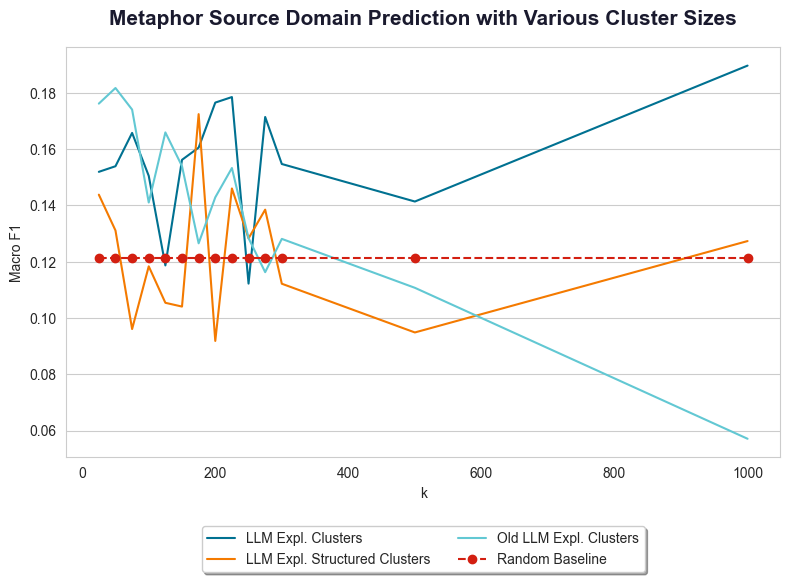

In [24]:
# PLOT THE RESULTS
plt.figure(figsize=(8, 6))

# o.g. 
# ["Random Baseline", "Source Group Cluster Model", "Tweet Cluster Model", "Best Combination"]
plt.plot(k, concept_met_clust_f1, c=blue_hex, ls='-', label='LLM Expl. Clusters')
plt.plot(k, concept_sc_met_clust_f1, c=orange_hex, ls='-', label='LLM Expl. Structured Clusters')
plt.plot(k, concept_met_or_clust_f1, c=teal_hex, ls='-', label='Old LLM Expl. Clusters')

# Plot the first line with red dashed style and circle markers
plt.plot(k, random, color=red_hex, linestyle='--', marker='o', label='Random Baseline')

plt.xlabel('k')
plt.ylabel(f"Macro F1")
plt.title("Metaphor Source Domain Prediction with Various Cluster Sizes", fontsize=15, fontweight="bold", pad=16, color="#1a1a2e")

# Position the legend below the plot
plt.legend(
    loc='upper center',         # Align the top center of the legend box
    bbox_to_anchor=(0.5, -0.15),# Anchor point: center horizontally (0.5), below axis (e.g., -0.15)
    ncol=2,                     # Display legend items in 4 columns
    fancybox=True,              # Add a fancy box style (optional)
    shadow=True                 # Add a shadow (optional)
)
plt.grid(axis='x') 
# plt.rc_context({"grid.linestyle": ":"})

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/concept_prediction.png", dpi=300)

In [25]:
# set up config and data loader
abortion_polarity_config = ExperimentConfig(
    dataset="subframes_abortion",
    labeled_only=False,
    task_type="evaluate_results",
    task_name="cluster_lr_results",
    logger=logger,
    env_vars=env_vars
)
data_loader = DatasetLoader(abortion_polarity_config)
abortion_res_path = f"{LR_RESULTS_DIR}/{abortion_polarity_config.dataset_out_name}/LABEL"

In [26]:
abortion_polarity_res_path = abortion_res_path.replace("LABEL", "polarity")
abortion_polarity_clust_path = f"{abortion_polarity_res_path}/mets_only_qwen_expl/"
abortion_polarity_clust_res = collect_results(abortion_polarity_clust_path)

In [27]:
# get random baseline - load results, predict over them
raw_data_dict = load_filtered_raw_data(abortion_polarity_config.dataset, abortion_polarity_config.labeled_only, ["polarity"], True, logger, data_loader)
df = pd.DataFrame.from_dict(raw_data_dict, orient='index')
random_macro_f1 = get_random_baseline(df, "polarity")
print(f"random macro f1: {random_macro_f1}")

2026-04-15 11:01:16,477 - cluster_lr_eval - INFO - Loaded 1276 doc entries
2026-04-15 11:01:16,477 - cluster_lr_eval - INFO - Loaded 1276 doc entries


Loaded 1276 doc entries
random macro f1: 0.523803024294572


In [28]:
# set k and get list of f1 values
k = sorted(list(abortion_polarity_clust_res.keys()))
k = [cur_k for cur_k in k if cur_k <= K_THRESH]

random = [random_macro_f1 for _ in k]
abortion_polarity_clust_f1 = [float(abortion_polarity_clust_res[cur_k]["all"].loc["macro avg", "f1-score"]) for cur_k in k]


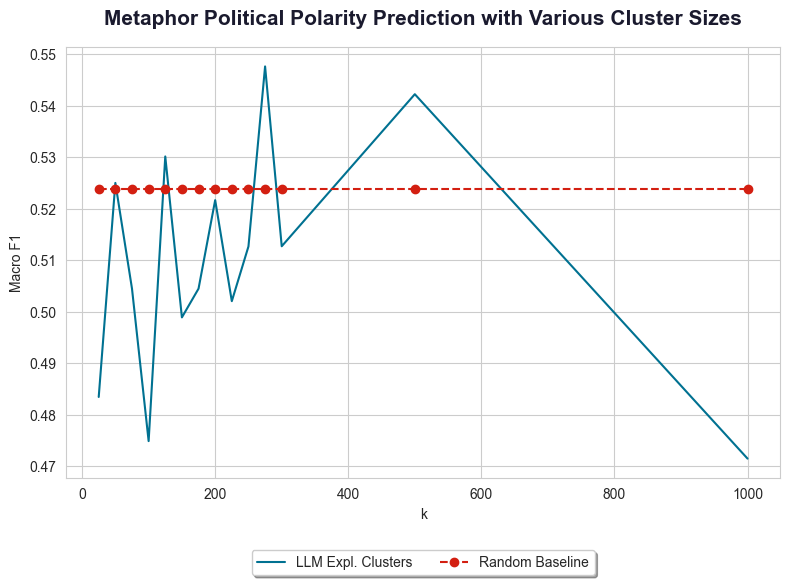

In [29]:
# PLOT THE RESULTS
plt.figure(figsize=(8, 6))

# o.g. 
# ["Random Baseline", "Source Group Cluster Model", "Tweet Cluster Model", "Best Combination"]
plt.plot(k, abortion_polarity_clust_f1, c=blue_hex, ls='-', label='LLM Expl. Clusters')

# Plot the first line with red dashed style and circle markers
plt.plot(k, random, color=red_hex, linestyle='--', marker='o', label='Random Baseline')

plt.xlabel('k')
plt.ylabel(f"Macro F1")
plt.title("Metaphor Political Polarity Prediction with Various Cluster Sizes", fontsize=15, fontweight="bold", pad=16, color="#1a1a2e")

# Position the legend below the plot
plt.legend(
    loc='upper center',         # Align the top center of the legend box
    bbox_to_anchor=(0.5, -0.15),# Anchor point: center horizontally (0.5), below axis (e.g., -0.15)
    ncol=2,                     # Display legend items in 4 columns
    fancybox=True,              # Add a fancy box style (optional)
    shadow=True                 # Add a shadow (optional)
)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/abortion_polarity_prediction.png", dpi=300)